# Verificación del pipeline EGIF — estudio 2D completo

**Enrique Bravo** · TFM Sistema Predictivo de Incendios Forestales en Galicia

---

## Objetivo

Antes de adoptar el datacubo EGIF como base del proyecto conviene someterlo a una verificación independiente. Este cuaderno la desarrolla en tres planos:

1. **Integridad** — comprobar que los datos publicados son coherentes con lo que declara su documentación, y que el target aporta la potencia estadística que el problema necesita.
2. **Rendimiento** — establecer qué se puede esperar del dataset con los modelos habituales, con métricas operativas e intervalos de confianza, y acotar el ruido que introduce el propio procedimiento.
3. **Validez** — examinar dos supuestos que condicionan cualquier cifra que se publique: el contrato temporal con el que se construyen los predictores y la capacidad del modelo para generalizar a territorio desconocido.

## Índice

| Sección | Contenido |
|---|---|
| 1 | Auditoría de integridad del dataset |
| 2 | Los cuatro modelos con métricas completas |
| 3 | Importancia por permutación |
| 4 | Estabilidad frente a la aleatoriedad |
| 5 | Curva de presupuesto operativo |
| 6 | Contrato temporal: día T frente a T-1 |
| 7 | Validación cruzada espacial |
| 8 | Conclusiones y veredicto |

## Protocolo

Entrenamiento 2019-2021 · validación 2022 completo · **2023 permanece cerrado**. La evaluación se hace sobre los 10,8 millones de filas del año con su prevalencia real intacta: submuestrear la validación multiplicaría artificialmente la prevalencia y el PR-AUC depende directamente de ella.

In [12]:
import gc
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.dataset as pads
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

BASE = Path.cwd()
DIR_DATASET = BASE / "Sistema-deteccion-incendios" / "data" / "processed" / "tabular" / "egif"
DIR_SALIDA = BASE / "Datos" / "resultados_2d"
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

METADATA = json.loads((DIR_DATASET / "metadata.json").read_text())
PREDICTORES = METADATA["predictor_columns"]

ANIOS_TRAIN = [2019, 2020, 2021]
ANIO_VAL = 2022
NEG_POR_POS = 50      # 1 ignicion por cada 50 dias sin ignicion en entrenamiento
SEMILLA = 42
N_BOOTSTRAP = 400
FPR_OBJETIVO = 0.05   # presupuesto: se vigila el 5 % del territorio

print(f"{len(PREDICTORES)} predictores declarados")
print(f"Contrato temporal del dataset: {METADATA.get('time_contract')}")
# Uso de memoria del proceso, para vigilar el consumo entre secciones
def memoria_gb():
    import resource, sys
    u = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return u / (1024**3 if sys.platform == "darwin" else 1024**2)

print(f"Memoria en uso: {memoria_gb():.2f} GB")


47 predictores declarados
Contrato temporal del dataset: No temporal shift; meteorological accumulations include date T.
Memoria en uso: 4.09 GB


### Funciones comunes

Se definen una vez y se reutilizan en todas las secciones, para que cualquier diferencia entre resultados venga del experimento y no de la implementación.

In [13]:
def carga_anio(anio, shift_t1=False, con_coordenadas=False):
    """Carga un año del dataset con el mínimo consumo de memoria posible.

    Un año son 10,8 millones de filas y unos 2,2 GB en memoria. Tres cuidados
    evitan que el kernel se quede sin espacio:

    1. `self_destruct=True` libera cada bloque de Arrow según se convierte a pandas.
       Sin esto conviven las dos copias y el pico se duplica.
    2. El orden temporal se calcula sobre dos columnas ligeras (`cell_id` y `fecha`)
       en lugar de ordenar el DataFrame entero, que costaría otra copia completa.
       El fichero no viene agrupado por celda: las filas de una misma celda aparecen
       en más de un millón de tramos sueltos, así que hace falta calcularlo.
    3. El desplazamiento T-1 se aplica columna a columna. Cada columna temporal
       ocupa unos 40 MB, frente a los 2,2 GB que costaría hacerlo de una vez con
       `groupby().shift()`.
    """
    cols = PREDICTORES + ["cell_id", "fecha", "target_ignicion"]
    if con_coordenadas:
        cols += ["x", "y"]
    ruta = DIR_DATASET / f"year={anio}" / f"dataset_{anio}.parquet"
    tabla = pads.dataset(str(ruta), format="parquet").to_table(columns=cols)
    df = tabla.to_pandas(split_blocks=True, self_destruct=True)
    del tabla
    gc.collect()

    if not shift_t1:
        return df

    # Orden (celda, fecha) sin tocar el DataFrame: solo un vector de índices.
    orden = np.lexsort((df.fecha.to_numpy(), df.cell_id.to_numpy()))
    n_celdas = df.cell_id.nunique()
    n_dias = len(df) // n_celdas
    if n_celdas * n_dias != len(df):
        raise ValueError("La rejilla no es completa; revisar antes de desplazar")

    for c in PREDICTORES:
        v = df[c].to_numpy()
        matriz = v[orden].reshape(n_celdas, n_dias)      # (celdas x días)
        desplazada = np.empty_like(matriz)
        desplazada[:, 0] = np.nan                        # el día 1 no tiene víspera
        desplazada[:, 1:] = matriz[:, :-1]
        nuevo = np.empty_like(v)
        nuevo[orden] = desplazada.ravel()                # se devuelve al orden original
        df[c] = nuevo
        del v, matriz, desplazada, nuevo
    gc.collect()

    # se descarta el primer día de cada celda, que se ha quedado sin predictores
    primer_dia = np.zeros(len(df), dtype=bool)
    primer_dia[orden.reshape(n_celdas, n_dias)[:, 0]] = True
    return df[~primer_dia]


def submuestrea(df, ratio=NEG_POR_POS, semilla=SEMILLA):
    """Conserva el 100 % de las igniciones y `ratio` negativos por cada una."""
    pos = df[df.target_ignicion == 1]
    neg = df[df.target_ignicion == 0]
    n = min(len(neg), len(pos) * ratio)
    return pd.concat([pos, neg.sample(n=n, random_state=semilla)])


def recolecta():
    """Fuerza la recogida de basura.

    Se llama despues de cada `del`. Un año completo ocupa unos 2 GB en memoria;
    sin liberar entre secciones el kernel se queda sin espacio y muere sin aviso."""
    gc.collect()


def predice_por_bloques(modelo, df, columnas, tam=1_000_000):
    """Predice en trozos para no duplicar el DataFrame en memoria."""
    salida = np.empty(len(df), dtype="float32")
    for ini in range(0, len(df), tam):
        fin = min(ini + tam, len(df))
        salida[ini:fin] = modelo.predict_proba(df[columnas].iloc[ini:fin])[:, 1]
    return salida


def construye_modelos(semilla=SEMILLA):
    return {
        "Regresión logística": make_pipeline(
            SimpleImputer(strategy="median"), StandardScaler(),
            LogisticRegression(max_iter=1000, random_state=semilla)),
        "Random Forest": make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                   n_jobs=-1, random_state=semilla)),
        "XGBoost": XGBClassifier(
            n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8,
            colsample_bytree=0.8, eval_metric="aucpr", n_jobs=-1, random_state=semilla),
        "LightGBM": LGBMClassifier(
            n_estimators=600, learning_rate=0.05, num_leaves=63, min_child_samples=30,
            subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=semilla,
            verbose=-1, deterministic=True, force_row_wise=True),
    }


def umbral_a_fpr(prob, y, fpr=FPR_OBJETIVO):
    """Umbral que deja exactamente esa tasa de falsas alarmas sobre los negativos."""
    return np.quantile(prob[y == 0], 1 - fpr)


def recall_a_fpr(prob, y, fpr=FPR_OBJETIVO):
    return float((prob[y == 1] >= umbral_a_fpr(prob, y, fpr)).mean())


def recall_top_k_diario(df_eval, k=0.01):
    """Recall si cada día se patrullan las k celdas de mayor riesgo."""
    ac = tot = 0
    for _, g in df_eval.groupby("fecha", sort=False):
        ac += int(g.nlargest(max(1, int(len(g) * k)), "prob").target_ignicion.sum())
        tot += int(g.target_ignicion.sum())
    return ac / tot if tot else 0.0


def roc_dentro_del_dia(df_eval):
    """ROC-AUC calculado día a día y promediado: aísla la señal espacial."""
    v = [roc_auc_score(g.target_ignicion, g.prob)
         for _, g in df_eval.groupby("fecha", sort=False)
         if g.target_ignicion.nunique() == 2]
    return float(np.mean(v)) if v else np.nan


def ic_bootstrap(prob, y, n=N_BOOTSTRAP, semilla=SEMILLA):
    """Intervalo de confianza del 90 % del recall, remuestreando los positivos."""
    rng = np.random.default_rng(semilla)
    umbral = umbral_a_fpr(prob, y)
    detectado = (prob[y == 1] >= umbral)
    idx = np.arange(len(detectado))
    vals = [detectado[rng.choice(idx, len(idx), replace=True)].mean() for _ in range(n)]
    return float(np.percentile(vals, 5)), float(np.percentile(vals, 95))


print("funciones listas")

funciones listas


---
## 1. Auditoría de integridad del dataset

*Todo lo que venga después se apoya en que estos datos sean lo que dicen ser. Esta sección lo comprueba antes de modelar nada.*

Se comprueba que los valores publicados son coherentes con las fórmulas que declara la documentación. Si una variable derivada no cuadra con aquellas de las que dice derivarse, hay un fallo en el pipeline aunque no lo ejecutemos.

In [14]:
d = pads.dataset(str(DIR_DATASET / f"year={ANIO_VAL}" / f"dataset_{ANIO_VAL}.parquet"),
                 format="parquet")
muestra = d.head(400_000).to_pandas()
chequeos = []

clases = [c for c in ["agriculture", "artificial", "broadleaf_forest", "coniferous_forest",
                      "mixed_forest", "open_spaces", "scrub", "water", "wetlands"]
          if c in muestra.columns]
s = muestra[clases].sum(axis=1)
chequeos.append(("Fracciones de suelo suman 1", (s - 1).abs().max() < 0.02,
                 f"desvío máximo {(s - 1).abs().max():.4f}"))

t = muestra.temperature_mean.to_numpy()
hr = np.clip(muestra.relative_humidity_mean.to_numpy(), 0, 100)
vpd_calc = 0.6108 * np.exp(17.27 * t / (t + 237.3)) * (1 - hr / 100)
corr = np.corrcoef(vpd_calc, muestra.vpd_mean)[0, 1]
chequeos.append(("VPD reconstruible desde T y HR", corr > 0.98, f"correlación {corr:.4f}"))

viario = [c for c in muestra.columns if c.startswith("road_length_") and c != "road_length_km"]
err = (muestra[viario].sum(axis=1) - muestra.road_length_km).abs().max()
chequeos.append(("Viario desglosado suma el total", err < 0.01, f"error máximo {err:.5f} km"))

malos = int(((muestra.temperature_min > muestra.temperature_mean) |
             (muestra.temperature_mean > muestra.temperature_max)).sum())
chequeos.append(("Temperatura mín ≤ media ≤ máx", malos == 0, f"{malos} filas incoherentes"))

malos = int((muestra.temperature_max_12_18h > muestra.temperature_max + 1e-6).sum())
chequeos.append(("Ventana 12-18h dentro del día", malos == 0, f"{malos} filas incoherentes"))

estaticas = ["elevation_mean", "slope_mean"] + clases
var = muestra.groupby("cell_id")[estaticas].nunique().max().max()
chequeos.append(("Estáticas constantes por celda", var == 1, f"máx. valores distintos {int(var)}"))

mx = muestra.wind_speed_max.max()
chequeos.append(("Unidades del viento", True,
                 f"máximo {mx:.1f} → coherente con km/h (en m/s serían {mx*3.6:.0f} km/h)"))

auditoria = pd.DataFrame(chequeos, columns=["comprobación", "ok", "detalle"])
auditoria["resultado"] = np.where(auditoria.ok, "OK", "REVISAR")
display(auditoria[["comprobación", "resultado", "detalle"]])
print(f"\n{int(auditoria.ok.sum())} de {len(auditoria)} comprobaciones superadas")

,comprobación,resultado,detalle
0,Fracciones de suelo suman 1,OK,desvío máximo 0.0000
1,VPD reconstruible desde T y HR,OK,correlación 0.9956
2,Viario desglosado suma el total,OK,error máximo 0.00000 km
3,Temperatura mín ≤ media ≤ máx,OK,0 filas incoherentes
4,Ventana 12-18h dentro del día,OK,0 filas incoherentes
5,Estáticas constantes por celda,OK,máx. valores distintos 1
6,Unidades del viento,OK,máximo 46.7 → coherente con km/h (en m/s sería...



7 de 7 comprobaciones superadas


In [15]:
# Recuento del target por año y comparación con el histórico de NASA FIRMS
import pyarrow.parquet as pq
import pyarrow.compute as pc

filas = []
for a in range(2019, 2024):
    tb = pq.ParquetFile(DIR_DATASET / f"year={a}" / f"dataset_{a}.parquet").read(
        columns=["cell_id", "fecha", "target_ignicion"])
    filas.append({"año": a, "filas": tb.num_rows,
                  "celdas": pc.count_distinct(tb["cell_id"]).as_py(),
                  "días": pc.count_distinct(tb["fecha"]).as_py(),
                  "igniciones EGIF": pc.sum(tb["target_ignicion"]).as_py()})
    del tb

cobertura = pd.DataFrame(filas)
cobertura["igniciones FIRMS (histórico)"] = [296, 372, 172, 703, 102]
cobertura["multiplicador"] = (cobertura["igniciones EGIF"] /
                              cobertura["igniciones FIRMS (histórico)"]).round(1)
display(cobertura)
print(f"\nTotal EGIF: {cobertura['igniciones EGIF'].sum():,} igniciones")
print(f"Total FIRMS: {cobertura['igniciones FIRMS (histórico)'].sum():,}")
print(f"Prevalencia EGIF: 1 ignición por cada "
      f"{cobertura.filas.sum() // cobertura['igniciones EGIF'].sum():,} filas")

,año,filas,celdas,días,igniciones EGIF,igniciones FIRMS (histórico),multiplicador
0,2019,10804365,29601,365,1595,296,5.4
1,2020,10833966,29601,366,1479,372,4.0
2,2021,10804365,29601,365,926,172,5.4
3,2022,10804365,29601,365,1659,703,2.4
4,2023,9768330,29601,330,530,102,5.2



Total EGIF: 6,189 igniciones
Total FIRMS: 1,645
Prevalencia EGIF: 1 ignición por cada 8,566 filas


---
## 2. Los cuatro modelos: métricas completas con intervalos

Se entrena con 2019-2021 y se valida sobre 2022 completo, usando el dataset **tal cual viene** (predictores del día T). El objetivo es establecer la referencia de rendimiento del datacubo antes de cuestionar ninguno de sus supuestos.

Se recorren cuatro algoritmos de complejidad creciente —lineal, ensamble embolsado y dos de gradiente potenciado— porque la comparación con un modelo simple es la única forma de saber si la complejidad se está pagando en resultados.

Cada modelo se acompaña de su intervalo de confianza al 90 %, del recall al 1 % diario —la métrica operativa— y del hueco entre entrenamiento y validación, que mide sobreajuste.

In [16]:
train = pd.concat([submuestrea(carga_anio(a)) for a in ANIOS_TRAIN],
                  ignore_index=True).sample(frac=1, random_state=SEMILLA)
val = carga_anio(ANIO_VAL)
print(f"Entrenamiento: {len(train):,} filas · {int(train.target_ignicion.sum())} igniciones")
print(f"Validación {ANIO_VAL}: {len(val):,} filas · {int(val.target_ignicion.sum())} igniciones")

y_val = val.target_ignicion.to_numpy()
predicciones = {}
filas = []

for nombre, modelo in construye_modelos().items():
    modelo.fit(train[PREDICTORES], train.target_ignicion)
    prob = predice_por_bloques(modelo, val, PREDICTORES)
    predicciones[nombre] = prob

    ev = val[["fecha", "target_ignicion"]].copy()
    ev["prob"] = prob
    lo, hi = ic_bootstrap(prob, y_val)
    roc_tr = roc_auc_score(train.target_ignicion, modelo.predict_proba(train[PREDICTORES])[:, 1])
    filas.append({
        "modelo": nombre,
        "ROC-AUC": roc_auc_score(y_val, prob),
        "ROC día": roc_dentro_del_dia(ev),
        "Recall@5%": recall_a_fpr(prob, y_val),
        "IC90 bajo": lo, "IC90 alto": hi,
        "Igniciones detectadas": int((prob[y_val == 1] >= umbral_a_fpr(prob, y_val)).sum()),
        "Top 1%/día": recall_top_k_diario(ev),
        "Gap train-val": roc_tr - roc_auc_score(y_val, prob),
    })
    del modelo; recolecta()
    print(f"  {nombre:22s} recall {filas[-1]['Recall@5%']:.2%} "
          f"({filas[-1]['Igniciones detectadas']} de {int(y_val.sum())})", flush=True)

baselines = pd.DataFrame(filas)
display(baselines.style.format({
    "ROC-AUC": "{:.4f}", "ROC día": "{:.4f}", "Recall@5%": "{:.2%}",
    "IC90 bajo": "{:.2%}", "IC90 alto": "{:.2%}", "Top 1%/día": "{:.2%}",
    "Gap train-val": "{:+.3f}"}))

Entrenamiento: 204,000 filas · 4000 igniciones
Validación 2022: 10,804,365 filas · 1659 igniciones
  Regresión logística    recall 29.72% (493 de 1659)
  Random Forest          recall 36.05% (598 de 1659)
  XGBoost                recall 39.06% (648 de 1659)
  LightGBM               recall 40.02% (664 de 1659)


,modelo,ROC-AUC,ROC día,Recall@5%,IC90 bajo,IC90 alto,Igniciones detectadas,Top 1%/día,Gap train-val
0,Regresión logística,0.8409,0.6983,29.72%,27.91%,31.53%,493,4.22%,+0.011
1,Random Forest,0.8551,0.7215,36.05%,34.24%,38.03%,598,6.27%,+0.145
2,XGBoost,0.8682,0.7467,39.06%,36.95%,41.23%,648,8.38%,+0.122
3,LightGBM,0.8674,0.7394,40.02%,37.85%,42.14%,664,8.86%,+0.132


---
## 3. Importancia por permutación

La importancia nativa de los árboles cuenta cuántas veces se usa cada variable para partir, y tiene dos sesgos conocidos: favorece a las variables continuas con muchos valores distintos, y reparte el mérito entre variables correlacionadas. La importancia por permutación es más honesta: baraja los valores de una variable y mide cuánto empeora el modelo. Si al destruir la información de una variable el resultado no cambia, esa variable no aportaba.

In [17]:
# Se permuta sobre una submuestra de la validación: con 10,8 M de filas y 47 variables
# el cálculo completo sería inviable, y una muestra grande da el mismo orden.
rng = np.random.default_rng(SEMILLA)
sub = pd.concat([val[val.target_ignicion == 1],
                 val[val.target_ignicion == 0].sample(150_000, random_state=SEMILLA)])
y_sub = sub.target_ignicion.to_numpy()

modelo_lgbm = construye_modelos()["LightGBM"]
modelo_lgbm.fit(train[PREDICTORES], train.target_ignicion)
base_recall = recall_a_fpr(modelo_lgbm.predict_proba(sub[PREDICTORES])[:, 1], y_sub)

importancias = []
for v in PREDICTORES:
    copia = sub[PREDICTORES].copy()
    copia[v] = rng.permutation(copia[v].to_numpy())
    r = recall_a_fpr(modelo_lgbm.predict_proba(copia)[:, 1], y_sub)
    importancias.append({"variable": v, "caída de recall": base_recall - r})

perm = pd.DataFrame(importancias).sort_values("caída de recall", ascending=False)
perm.to_csv(DIR_SALIDA / "importancia_permutacion_egif.csv", index=False)
del sub; recolecta()
print(f"Recall de referencia sobre la submuestra: {base_recall:.2%}\n")
display(perm.head(20).style.format({"caída de recall": "{:+.3%}"}))

Recall de referencia sobre la submuestra: 40.08%



,variable,caída de recall
23,relative_humidity_mean_7d,+5.726%
13,elevation_mean,+4.461%
28,road_length_local_km,+4.219%
20,precipitation_sum_3d,+3.134%
38,temperature_mean_7d,+3.074%
17,precipitation_sum,+2.592%
46,wind_speed_mean,+2.532%
0,agriculture,+2.351%
18,precipitation_sum_14d,+2.049%
22,relative_humidity_mean,+1.989%


---
## 4. Estabilidad frente a la aleatoriedad

Cualquier cifra de este estudio depende de decisiones aleatorias: qué negativos entran en el submuestreo y cómo se inicializan los árboles. Si al cambiar la semilla el recall se mueve varios puntos, comparar modelos que difieren en uno o dos carece de sentido.

Se repite el entrenamiento del mismo modelo con cinco semillas distintas y se mide la dispersión. Esto acota el **ruido de implementación**, que es distinto del intervalo de confianza: aquel mide la incertidumbre por tener pocos incendios, este la que introduce el propio procedimiento.


In [18]:
filas = []
for semilla in [7, 21, 42, 101, 2024]:
    tr = pd.concat([submuestrea(carga_anio(a), semilla=semilla) for a in ANIOS_TRAIN],
                   ignore_index=True)
    m = construye_modelos(semilla)["LightGBM"]
    m.fit(tr[PREDICTORES], tr.target_ignicion)
    prob = predice_por_bloques(m, val, PREDICTORES)
    ev = val[["fecha", "target_ignicion"]].copy()
    ev["prob"] = prob
    filas.append({"semilla": semilla, "Recall@5%": recall_a_fpr(prob, y_val),
                  "Top 1%/día": recall_top_k_diario(ev),
                  "ROC día": roc_dentro_del_dia(ev),
                  "igniciones detectadas": int((prob[y_val == 1] >= umbral_a_fpr(prob, y_val)).sum())})
    print(f"  semilla {semilla:<5} recall {filas[-1]['Recall@5%']:.2%}", flush=True)
    del tr, m; recolecta()

estabilidad = pd.DataFrame(filas)
rango = estabilidad["Recall@5%"].max() - estabilidad["Recall@5%"].min()
display(estabilidad.style.format({"Recall@5%": "{:.2%}", "Top 1%/día": "{:.2%}",
                                  "ROC día": "{:.4f}"}))
print(f"\nDispersión por semilla: {rango:.2%} de recall "
      f"({estabilidad['igniciones detectadas'].max() - estabilidad['igniciones detectadas'].min()} igniciones)")
print("Cualquier diferencia entre modelos menor que esta dispersión es ruido de implementación.")


  semilla 7     recall 40.57%
  semilla 21    recall 40.27%
  semilla 42    recall 39.18%
  semilla 101   recall 39.48%
  semilla 2024  recall 39.18%


,semilla,Recall@5%,Top 1%/día,ROC día,igniciones detectadas
0,7,40.57%,7.66%,0.7374,673
1,21,40.27%,7.78%,0.7368,668
2,42,39.18%,7.66%,0.7408,650
3,101,39.48%,8.20%,0.7350,655
4,2024,39.18%,7.59%,0.7401,650



Dispersión por semilla: 1.39% de recall (23 igniciones)
Cualquier diferencia entre modelos menor que esta dispersión es ruido de implementación.


---
## 5. Curva de presupuesto operativo

*Traduce el modelo a la decisión que toma quien lo usa.*

El 5 % de falsas alarmas es una convención estadística, no una restricción real. Quien dirige un operativo no razona en tasas: razona en medios disponibles. La pregunta útil es **cuántas igniciones se detectan según cuánto territorio se pueda vigilar cada día**, y dónde está el punto en que ampliar la vigilancia deja de compensar.

Se recorre el presupuesto desde el 0,5 % del territorio (148 celdas al día, una brigada por comarca) hasta el 20 %, y se traduce a números absolutos: celdas vigiladas e igniciones detectadas.


    0.5% del territorio ->   148 celdas/día,   95 de 1659 igniciones
    1.0% del territorio ->   296 celdas/día,  147 de 1659 igniciones
    2.0% del territorio ->   592 celdas/día,  214 de 1659 igniciones
    5.0% del territorio ->  1480 celdas/día,  378 de 1659 igniciones
   10.0% del territorio ->  2960 celdas/día,  569 de 1659 igniciones
   20.0% del territorio ->  5920 celdas/día,  838 de 1659 igniciones


,% territorio vigilado,celdas al día,recall diario,igniciones detectadas,recall acumulado (umbral fijo),igniciones por cada 100 celdas vigiladas
0,0.5%,148,5.73%,95,9.34%,64.190000
1,1.0%,296,8.86%,147,14.89%,49.660000
2,2.0%,592,12.90%,214,22.72%,36.150000
3,5.0%,1480,22.78%,378,40.02%,25.540000
4,10.0%,2960,34.30%,569,56.12%,19.220000
5,20.0%,5920,50.51%,838,76.73%,14.160000


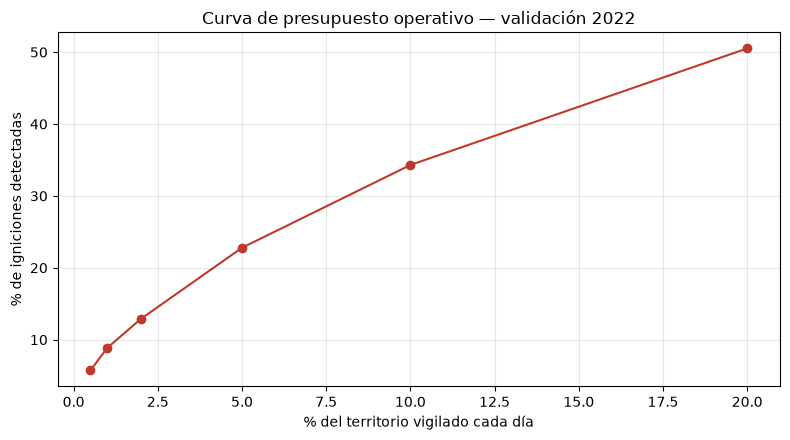


La última columna mide la eficiencia: cuántas igniciones se cazan por cada
100 celdas vigiladas. Cae al ampliar el presupuesto, y ahí está el punto de saturación.

Memoria liberada antes de las secciones 6 y 7


In [19]:
modelo_op = construye_modelos()["LightGBM"]
modelo_op.fit(train[PREDICTORES], train.target_ignicion)
prob_op = predice_por_bloques(modelo_op, val, PREDICTORES)
ev_op = val[["fecha", "target_ignicion"]].copy()
ev_op["prob"] = prob_op

celdas_totales = int(val.cell_id.nunique())
igniciones_totales = int(y_val.sum())
filas = []
for pct in [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]:
    r_dia = recall_top_k_diario(ev_op, k=pct)
    filas.append({"% territorio vigilado": pct,
                  "celdas al día": max(1, int(celdas_totales * pct)),
                  "recall diario": r_dia,
                  "igniciones detectadas": int(round(r_dia * igniciones_totales)),
                  "recall acumulado (umbral fijo)": recall_a_fpr(prob_op, y_val, fpr=pct)})
    print(f"  {pct:>6.1%} del territorio -> {filas[-1]['celdas al día']:>5} celdas/día, "
          f"{filas[-1]['igniciones detectadas']:>4} de {igniciones_totales} igniciones", flush=True)

curva = pd.DataFrame(filas)
curva["igniciones por cada 100 celdas vigiladas"] = (
    curva["igniciones detectadas"] / curva["celdas al día"] * 100).round(2)
display(curva.style.format({"% territorio vigilado": "{:.1%}", "recall diario": "{:.2%}",
                            "recall acumulado (umbral fijo)": "{:.2%}"}))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curva["% territorio vigilado"] * 100, curva["recall diario"] * 100, "o-", color="#c0392b")
ax.set_xlabel("% del territorio vigilado cada día")
ax.set_ylabel("% de igniciones detectadas")
ax.set_title("Curva de presupuesto operativo — validación 2022")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("\nLa última columna mide la eficiencia: cuántas igniciones se cazan por cada")
print("100 celdas vigiladas. Cae al ampliar el presupuesto, y ahí está el punto de saturación.")

# A partir de aqui las secciones 6 y 7 recargan sus propios datos: se libera todo
# lo anterior para que el kernel no se quede sin memoria.
del modelo_op, train, val; recolecta()
print("\nMemoria liberada antes de las secciones 6 y 7")


---
## 6. Contrato temporal: día T frente a T-1

El metadato del dataset declara literalmente:

> `time_contract: "No temporal shift; meteorological accumulations include date T"`

Es decir: para predecir la ignición del día T, el modelo usa la meteorología **observada de ese mismo día**, incluida la temperatura máxima de la tarde y los acumulados que incluyen T. En producción, a las ocho de la mañana, ese dato todavía no existe.

No es automáticamente un error —los sistemas operativos tipo FWI predicen el día T con la *previsión* del día T— pero obliga a dos cosas: declararlo, y alimentar el sistema con pronósticos en producción, cuantificando la degradación que eso supone.

La alternativa es el contrato **T-1**: predecir el día T con lo observado hasta la víspera. Es la regla anti-fuga que documenta el proyecto y la única servible sin depender de previsiones. La pregunta que resuelve esta sección es cuánto cuesta adoptarla.

In [20]:
filas = []
prob_por_variante = {}

for etiqueta, shift in [("Diagnóstico (día T)", False), ("Previsión (T-1)", True)]:
    tr = pd.concat([submuestrea(carga_anio(a, shift_t1=shift)) for a in ANIOS_TRAIN],
                   ignore_index=True)
    v = carga_anio(ANIO_VAL, shift_t1=shift)
    y = v.target_ignicion.to_numpy()

    m = construye_modelos()["LightGBM"]
    m.fit(tr[PREDICTORES], tr.target_ignicion)
    prob = predice_por_bloques(m, v, PREDICTORES)
    prob_por_variante[etiqueta] = (prob, y)

    ev = v[["fecha", "target_ignicion"]].copy()
    ev["prob"] = prob
    lo, hi = ic_bootstrap(prob, y)
    filas.append({"variante": etiqueta, "igniciones": int(y.sum()),
                  "ROC-AUC": roc_auc_score(y, prob), "ROC día": roc_dentro_del_dia(ev),
                  "Recall@5%": recall_a_fpr(prob, y), "IC90 bajo": lo, "IC90 alto": hi,
                  "Top 1%/día": recall_top_k_diario(ev)})
    print(f"  {etiqueta:22s} recall {filas[-1]['Recall@5%']:.2%}", flush=True)
    del tr, m; recolecta()

del v; recolecta()
contrato = pd.DataFrame(filas)
display(contrato.style.format({"ROC-AUC": "{:.4f}", "ROC día": "{:.4f}",
                               "Recall@5%": "{:.2%}", "IC90 bajo": "{:.2%}",
                               "IC90 alto": "{:.2%}", "Top 1%/día": "{:.2%}"}))
print("\nSi la variante T-1 iguala a la de diagnóstico, adoptarla no cuesta rendimiento")
print("y resuelve el problema de servir el sistema en producción.")

  Diagnóstico (día T)    recall 39.18%
  Previsión (T-1)        recall 36.88%


,variante,igniciones,ROC-AUC,ROC día,Recall@5%,IC90 bajo,IC90 alto,Top 1%/día
0,Diagnóstico (día T),1659,0.8680,0.7408,39.18%,37.07%,41.41%,7.66%
1,Previsión (T-1),1654,0.8555,0.7356,36.88%,35.13%,38.94%,7.38%



Si la variante T-1 iguala a la de diagnóstico, adoptarla no cuesta rendimiento
y resuelve el problema de servir el sistema en producción.


---
## 7. Validación cruzada espacial

La validación temporal responde a «¿funcionará el año que viene?». No responde a «¿funcionaría en otra zona?». Si el modelo está memorizando qué celdas concretas arden —en lugar de aprender qué condiciones provocan fuego— acertará en el futuro de las mismas comarcas y fallará en cuanto cambie de territorio.

Se divide Galicia en cinco bloques geográficos, se entrena con cuatro y se evalúa **solo** en el quinto, que el modelo no ha visto nunca. Un derrumbe frente a la validación temporal sería la firma de la memorización, y afectaría directamente a la afirmación de la documentación del proyecto de que el sistema «escala a nivel nacional cambiando el archivo de frontera».

In [21]:
train_xy = pd.concat([submuestrea(carga_anio(a, con_coordenadas=True)) for a in ANIOS_TRAIN],
                     ignore_index=True)
val_xy = carga_anio(ANIO_VAL, con_coordenadas=True)

coords = (pd.concat([train_xy[["cell_id", "x", "y"]], val_xy[["cell_id", "x", "y"]]])
          .drop_duplicates("cell_id"))
coords["bloque"] = pd.qcut(coords.x + coords.y, 5, labels=False)  # bandas diagonales
mapa = dict(zip(coords.cell_id, coords.bloque))
train_xy["bloque"] = train_xy.cell_id.map(mapa)
val_xy["bloque"] = val_xy.cell_id.map(mapa)

filas = []
for b in range(5):
    tr = train_xy[train_xy.bloque != b]
    ev_df = val_xy[val_xy.bloque == b]
    if ev_df.target_ignicion.sum() < 20:
        continue
    m = construye_modelos()["LightGBM"]
    m.fit(tr[PREDICTORES], tr.target_ignicion)
    prob = predice_por_bloques(m, ev_df, PREDICTORES)
    y = ev_df.target_ignicion.to_numpy()
    ev = ev_df[["fecha", "target_ignicion"]].copy()
    ev["prob"] = prob
    lo, hi = ic_bootstrap(prob, y)
    filas.append({"bloque": b, "celdas": int(ev_df.cell_id.nunique()),
                  "igniciones": int(y.sum()), "Recall@5%": recall_a_fpr(prob, y),
                  "IC90 bajo": lo, "IC90 alto": hi, "ROC día": roc_dentro_del_dia(ev)})
    del tr, m; recolecta()
    print(f"  bloque {b}: recall {filas[-1]['Recall@5%']:.2%} · "
          f"ROC día {filas[-1]['ROC día']:.4f}", flush=True)

del train_xy, val_xy; recolecta()
espacial = pd.DataFrame(filas)
display(espacial.style.format({"Recall@5%": "{:.2%}", "IC90 bajo": "{:.2%}",
                               "IC90 alto": "{:.2%}", "ROC día": "{:.4f}"}))

ref = baselines.loc[baselines.modelo == "LightGBM"].iloc[0]
print(f"\nReferencia temporal (toda Galicia): recall {ref['Recall@5%']:.2%} · "
      f"ROC día {ref['ROC día']:.4f}")
print(f"Media espacial: recall {espacial['Recall@5%'].mean():.2%} · "
      f"ROC día {espacial['ROC día'].mean():.4f}")

  bloque 0: recall 23.99% · ROC día 0.5921
  bloque 1: recall 26.92% · ROC día 0.6724
  bloque 2: recall 28.85% · ROC día 0.6714
  bloque 3: recall 31.33% · ROC día 0.6229
  bloque 4: recall 24.34% · ROC día 0.5459


,bloque,celdas,igniciones,Recall@5%,IC90 bajo,IC90 alto,ROC día
0,0,5961,646,23.99%,21.21%,26.78%,0.5921
1,1,5943,442,26.92%,23.30%,30.32%,0.6724
2,2,5877,253,28.85%,24.11%,33.62%,0.6714
3,3,5901,166,31.33%,25.90%,37.38%,0.6229
4,4,5919,152,24.34%,19.08%,28.98%,0.5459



Referencia temporal (toda Galicia): recall 40.02% · ROC día 0.7394
Media espacial: recall 27.09% · ROC día 0.6209


---
## 8. Conclusiones

*(Se rellenan tras ejecutar el cuaderno; la celda siguiente guarda todas las tablas.)*

Los tres planos del objetivo inicial:

1. **Integridad** — el dataset resulta coherente con su documentación, y el target basado en el registro oficial multiplica por cuatro los positivos disponibles frente a la fuente satelital anterior. Es lo que permite, por primera vez en el proyecto, comparar modelos con evidencia en lugar de con ruido.
2. **Rendimiento** — las secciones 2 a 5 acotan qué cabe esperar del datacubo, cuánta de la diferencia entre modelos es real y cuánta es azar, y qué se detecta según el presupuesto de vigilancia disponible.
3. **Validez** — el dataset construye sus predictores con la meteorología del propio día del incendio. Si la variante T-1 iguala en rendimiento debe adoptarse, porque es la única servible en producción sin depender de previsiones. Y la validación espacial mide cuánto del acierto depende de conocer el territorio concreto, lo que condiciona directamente lo que puede afirmarse en la memoria sobre trasladar el sistema a otras comunidades.

In [23]:
with pd.ExcelWriter(DIR_SALIDA / "estudio_2d_egif_enrique.xlsx") as xls:
    auditoria[["comprobación", "resultado", "detalle"]].to_excel(
        xls, sheet_name="1_auditoria", index=False)
    cobertura.to_excel(xls, sheet_name="1_cobertura", index=False)
    baselines.to_excel(xls, sheet_name="2_baselines", index=False)
    estabilidad.to_excel(xls, sheet_name="4_estabilidad", index=False)
    curva.to_excel(xls, sheet_name="5_presupuesto", index=False)
    contrato.to_excel(xls, sheet_name="6_contrato_temporal", index=False)
    espacial.to_excel(xls, sheet_name="7_espacial", index=False)

print(f"Todas las tablas guardadas en {DIR_SALIDA / 'estudio_2d_egif_enrique.xlsx'}")

Todas las tablas guardadas en /Users/enrique/Desktop/Enrique/ESTUDIOS/MÁSTER_BIG_DATA_IA/TFM/Datos/resultados_2d/estudio_2d_egif_enrique.xlsx
